In [ ]:
%pip install pytesseract
%pip install opencv-python
!sudo apt-get install -y tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
%pip install matplotlib

Original Image:


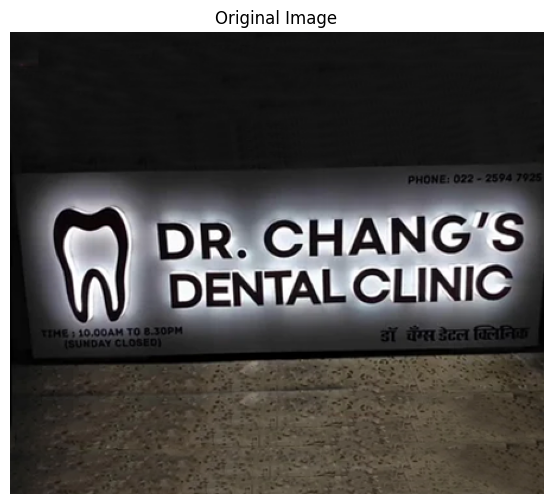


=== OPTION 1: Direct OCR ===
Direct OCR result:
DR. CHANG’S
DENTAL CLINIC


=== OPTION 2: Denoising ===
Denoised and thresholded image:


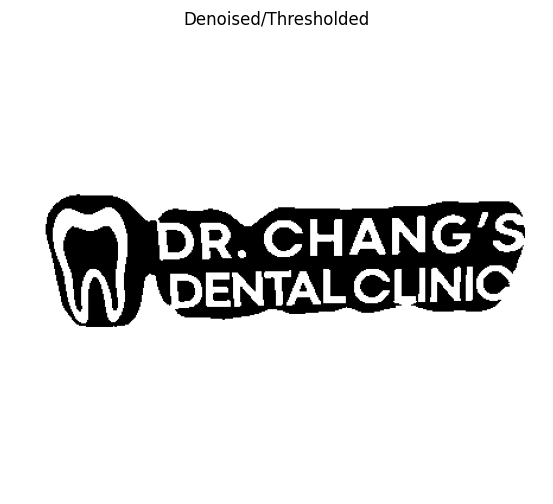

Denoised OCR result:
DR. CHANG’S
DENTAL CLINIC


=== OPTION 3: Adaptive Thresholding ===
Adaptive threshold image:


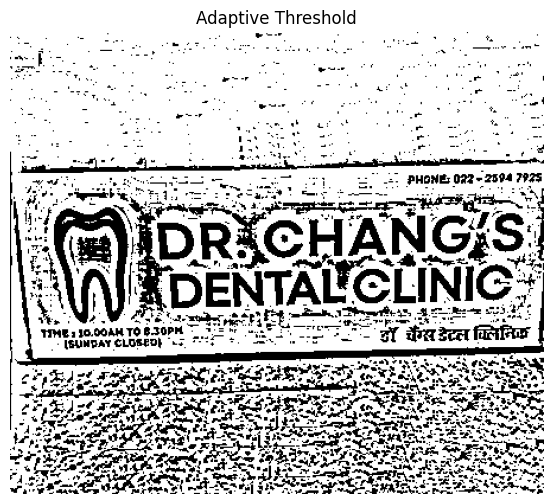

Adaptive OCR result:
ph ES ens
DOE eg ESOS Ry epee EL. Se on MONE ORCAS
Ue a i REGHANGIS:
G)IDRECHANG:S:
EAN RDENTALCLINIC

BIA TA 3 teehee leer te at eet

TmeEggQeeATeegSN eee aes a of deca fo
chee coe FG ee EN SH eet STAN
[ERS ES
RD RIG TEM AR ORE NCEA DS
Fie, REIN ae ti ed Te S oa yetGTENE EN Ne


=== OPTION 4: Morphological Operations ===
After dilation/erosion:


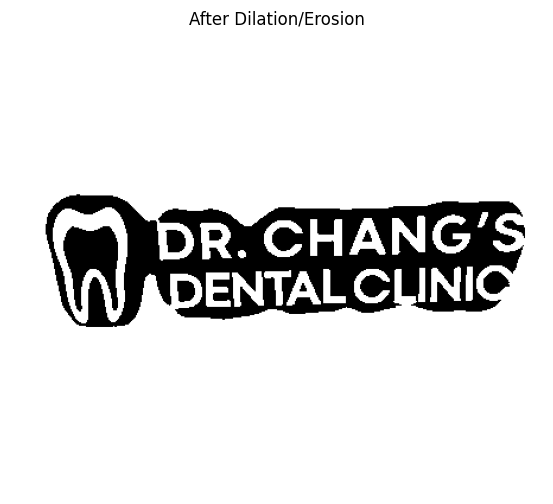

Morphological OCR result:
DR. CHANG’S
DENTAL CLINIC



In [16]:
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

def show_image(img, title=None, figsize=(10,6)):
    plt.figure(figsize=figsize)
    if hasattr(img, 'ndim') and img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    plt.axis('off')
    if title:
        plt.title(title)
    display(plt.gcf())
    plt.close()

def get_ocr_text(image_path):
    try:
        # Load the image
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Error: Image not found at {image_path}")

        print("Original Image:")
        show_image(img, "Original Image")

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # OPTION 1: Direct approach (simplest - usually works best)
        print("\n=== OPTION 1: Direct OCR ===")
        text_direct = pytesseract.image_to_string(gray, config='--oem 3 --psm 6')
        print(f"Direct OCR result:\n{text_direct}")

        # OPTION 2: Denoising and thresholding
        print("\n=== OPTION 2: Denoising ===")
        # Remove noise
        denoised = cv2.fastNlMeansDenoising(gray, h=30)

        # Apply threshold
        _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Check if text is white on black (invert if needed)
        # Count white vs black pixels in top-left corner
        if np.mean(thresh[:50, :50]) < 127:
            thresh = cv2.bitwise_not(thresh)

        print("Denoised and thresholded image:")
        show_image(thresh, "Denoised/Thresholded")

        text_denoised = pytesseract.image_to_string(thresh, config='--oem 3 --psm 6')
        print(f"Denoised OCR result:\n{text_denoised}")

        # OPTION 3: Adaptive thresholding (for varying lighting)
        print("\n=== OPTION 3: Adaptive Thresholding ===")
        adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 15, 2)
        print("Adaptive threshold image:")
        show_image(adaptive, "Adaptive Threshold")

        text_adaptive = pytesseract.image_to_string(adaptive, config='--oem 3 --psm 6')
        print(f"Adaptive OCR result:\n{text_adaptive}")

        # OPTION 4: With dilation/erosion (for broken text)
        print("\n=== OPTION 4: Morphological Operations ===")
        kernel = np.ones((1, 1), np.uint8)
        dilated = cv2.dilate(thresh, kernel, iterations=1)
        eroded = cv2.erode(dilated, kernel, iterations=1)

        print("After dilation/erosion:")
        show_image(eroded, "After Dilation/Erosion")

        text_morph = pytesseract.image_to_string(eroded, config='--oem 3 --psm 6')
        print(f"Morphological OCR result:\n{text_morph}")

    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
        return None

# Test the function
image_file = '/content/sample1.jpg'  # Change to your actual filename
extracted_text = get_ocr_text('9860p25.png')

In [ ]:
import cv2
import pytesseract
import numpy as np

def get_better_ocr_system(image_path):
    try:
        # Load the image
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Error: Image not found at {image_path}")

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Remove noise
        denoised = cv2.fastNlMeansDenoising(gray, h=30)

        # Apply threshold
        _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Invert if needed (ensure black text on white background)
        if np.mean(thresh[:50, :50]) < 127:
            thresh = cv2.bitwise_not(thresh)

        # Perform OCR
        extracted_text = pytesseract.image_to_string(thresh, config='--oem 3 --psm 6')

        return extracted_text.strip()

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Test the function
image_file = '/content/hanging-signboard-mockup.jpg'
extracted_text = get_better_ocr_system('9860p25.png')

if extracted_text:
    print(extracted_text)

a
